# Checking yields

In [1]:
%%time
%run 'load-data.ipynb'

Building DAG of jobs...
Loading files from %s root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated
Loading files from %s root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated
['root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated/rds_final_2012_13563002_magdown_rs.root', 'root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated/rds_final_2012_13563002_magup_rs.root']
Loading files from %s root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated
Loading files from %s root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process_data/validated
Loading files from %s root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated
['root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated/rds_final_2012_13763200_magdown_None.root', 'r

In [2]:
len(data)

73852

In [3]:
len(mc_norm)

225177

In [4]:
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.figsize"] = (15,6)

In [5]:
def mygroupby(d, groupbycols):
    """ Utility to group by a column and show relative statistics """
    g = d.groupby(groupbycols).size().reset_index(name='count').sort_values([ 'count'], ascending=False).reset_index(drop=True)
    g["Percentage"] = g.apply(lambda row: 100 * row["count"]/d.shape[0], axis=1)
    g["cumulative %"] = g["Percentage"].cumsum(axis = 0)
    return g

## Checking the Bs to Ds3pi MC

In [6]:
len(ds3pi_norm)

45804

In [7]:
d2 = ds3pi_norm.query("B_M > 5000"); print(f"After B_M: {len(d2)}")
d2 = d2.query("BDT_Iso > 0.03458"); print(f"After BDT_Iso: {len(d2)}")
d2 = d2.query("Xc_Selection > 0"); print(f"After Xc_Selection: {len(d2)}")
d2 = d2.query("B_Y_SEP > -4.5"); print(f"After B_Y_SEP > -4.5: {len(d2)}")
d2 = d2.query("B_M > 5346 and B_M < 5386"); print(f"After B_M peak cut: {len(d2)}")
d2 = d2.query("category == 2"); print(f"After check category: {len(d2)}")


After B_M: 45804
After BDT_Iso: 45804
After Xc_Selection: 45804
After B_Y_SEP > -4.5: 45613
After B_M peak cut: 35760
After check category: 32541


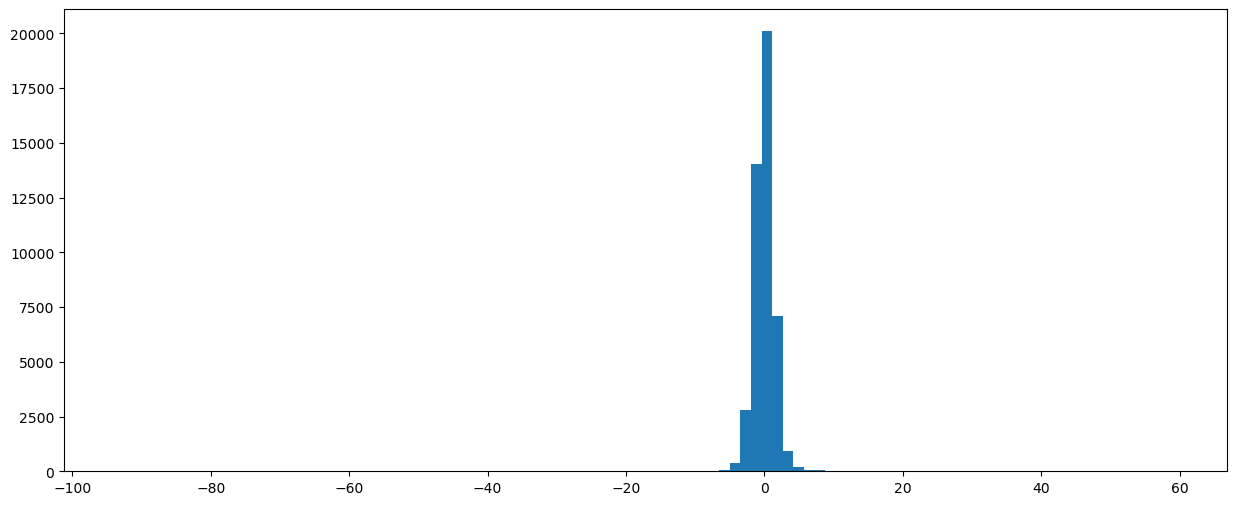

In [9]:
plt.hist(ds3pi_norm.B_Y_SEP, bins=100);

## Checking the Dstar tau nu MC

In [10]:
len(mcdstartaunu)

51772

In [19]:
print(f"After TD: {len(mcdstartaunu)}")
d2 = mcdstartaunu.query("BDT_Iso > 0.03458"); print(f"After BDT_Iso: {len(d2)}")
d2 = d2.query("Xc_Selection > 0"); print(f"After Xc_Selection: {len(d2)}")
d2 = d2.query("B_Y_SEP < -4.5"); print(f"After B_Y_SEP < -4.5: {len(d2)}")
d2 = d2.query("q2_2 > 0"); print(f"After q2_2 > 0: {len(d2)}")
d2 = d2.query("abs(mN2v)<250e6"); print(f"After mN2v: {len(d2)}")
dcut1 = d2.query("bdt_dc > 0.75"); print(f"After CUT1: {len(dcut1)}")
dcut2 = d2.query("bdt_dc > 0.35"); print(f"After CUT2: {len(dcut2)}")
dcut3 = d2.query("bdt_dc > 0.5"); print(f"After CUT3: {len(dcut3)}")



BEFORE: 51772
After BDT_Iso: 51772
After Xc_Selection: 51772
After B_Y_SEP < -4.5: 21886
After q2_2 > 0: 21886
After mN2v: 21886
After CUT1: 10032
After CUT2: 20382
After CUT3: 18055


## Some statistics

In [16]:
mc_norm_sup5000 = mc_norm.query("B_M > 5000")

In [17]:
len(mc_norm_sup5000)

225177

In [18]:
mc_norm_peak = mc_norm.query("B_M > 5346 & B_M < 5386")

In [19]:
len(mc_norm_peak)

70345

In [20]:
mygroupby(mc_norm_peak, "key")

,key,count,Percentage,cumulative %
0,Xc_signal_Ypis_B_vertex_fromBs,61982,88.111451,88.111451
1,Xc_background,4648,6.607435,94.718885
2,Xc_signal_Ypis_nomatch_Prompt,2435,3.461511,98.180397
3,Xc_signal_Ypis_displaced_fromBs_fromDs,741,1.053380,99.233776
4,Xc_signal_Ypis_diffVertex_normlike,214,0.304215,99.537991
5,Xc_signal_Ypis_nomatch_doubleCharm,129,0.183382,99.721373
6,Xc_signal_Ypis_diffAncestorYXc,49,0.069657,99.791030
7,Xc_signal_Ypis_displaced_fromLambdab_fromLambdac,46,0.065392,99.856422
8,Xc_signal_Ypis_nomatch_charmStrange,43,0.061127,99.917549
9,Xc_signal_Ypis_displaced_fromBs_fromDp,16,0.022745,99.940294


In [21]:
data_norm_peak = data_norm.query("B_M > 5346 & B_M < 5386")

In [22]:
len(mc_norm_peak)

5899

In [24]:
len(mc_norm_peak)/len(data_norm_peak)

11.92490252585184

## Checking the B mass

In [ ]:
myrange=None
plt.hist(data_norm.B_M, bins=300, 
         label= 'data', histtype='step', density=True, range=myrange);
plt.hist(mc_norm.B_M, bins=300, 
         label= 'mc', histtype='step', density=True, range=myrange);

plt.legend();

In [ ]:
data_norm_p = data_norm.query("B_M > 5326 & B_M < 5406")
mc_norm_p = mc_norm.query("B_M > 5326 & B_M < 5406")

In [ ]:
myrange=None
dres = plt.hist(data_norm_p.B_M, bins=200, 
         label= 'data', histtype='step', range=myrange);
mcres = plt.hist(mc_norm_p.B_M, bins=200, 
         label= 'mc', histtype='step', range=myrange);
plt.legend();

In [ ]:
print(f"Ratio MC/data for canditates with 5326 < B_M < 5406: {mc_norm_p.shape[0]/data_norm_p.shape[0]}")

In [11]:
mygroupby(mc_norm_p, "key")

,key,count,Percentage,cumulative %
0,Xc_signal_Ypis_B_vertex_fromBs,75821,86.850093,86.850093
1,Xc_background,6166,7.062920,93.913014
2,Xc_signal_Ypis_nomatch_Prompt,3460,3.963299,97.876313
3,Xc_signal_Ypis_displaced_fromBs_fromDs,930,1.065280,98.941593
4,Xc_signal_Ypis_diffVertex_normlike,304,0.348221,99.289813
5,Xc_signal_Ypis_nomatch_doubleCharm,235,0.269184,99.558997
6,Xc_signal_Ypis_displaced_fromLambdab_fromLambdac,100,0.114546,99.673543
7,Xc_signal_Ypis_diffAncestorYXc,88,0.100801,99.774344
8,Xc_signal_Ypis_nomatch_charmStrange,79,0.090492,99.864835
9,Xc_signal_Ypis_displaced_fromBs_fromDp,30,0.034364,99.899199


In [12]:
data_norm_p = data_norm.query("B_M > 5346 & B_M < 5386")
mc_norm_p = mc_norm.query("B_M > 5346 & B_M < 5386")

In [20]:
mygroupby(mc_norm_p, "key")

,key,count,Percentage,cumulative %
0,Xc_signal_Ypis_B_vertex_fromBs,55405,89.511608,89.511608
1,Xc_background,3196,5.163417,94.675025
2,Xc_signal_Ypis_nomatch_Prompt,2173,3.510671,98.185696
3,Xc_signal_Ypis_displaced_fromBs_fromDs,655,1.058210,99.243905
4,Xc_signal_Ypis_diffVertex_normlike,182,0.294037,99.537942
5,Xc_signal_Ypis_nomatch_doubleCharm,119,0.192255,99.730197
6,Xc_signal_Ypis_displaced_fromLambdab_fromLambdac,42,0.067855,99.798052
7,Xc_signal_Ypis_diffAncestorYXc,39,0.063008,99.861060
8,Xc_signal_Ypis_nomatch_charmStrange,36,0.058161,99.919221
9,Xc_signal_Ypis_displaced_fromBs_fromDp,13,0.021003,99.940223


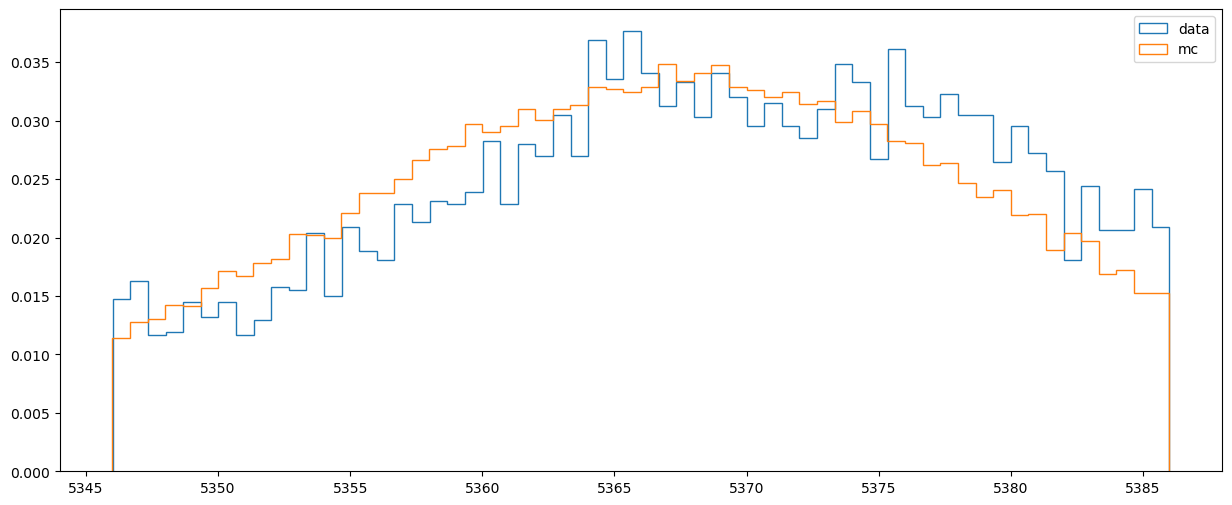

In [13]:
myrange=None
dres = plt.hist(data_norm_p.B_M, bins=60, 
         label= 'data', histtype='step', range=myrange, density=True);
mcres = plt.hist(mc_norm_p.B_M, bins=60, 
         label= 'mc', histtype='step', range=myrange, density=True);
plt.legend();

In [14]:
print(f"Ratio MC/data for canditates with 5346 < B_M < 5386: {mc_norm_p.shape[0]/data_norm_p.shape[0]}")

Ratio MC/data for canditates with 5346 < B_M < 5386: 11.92490252585184


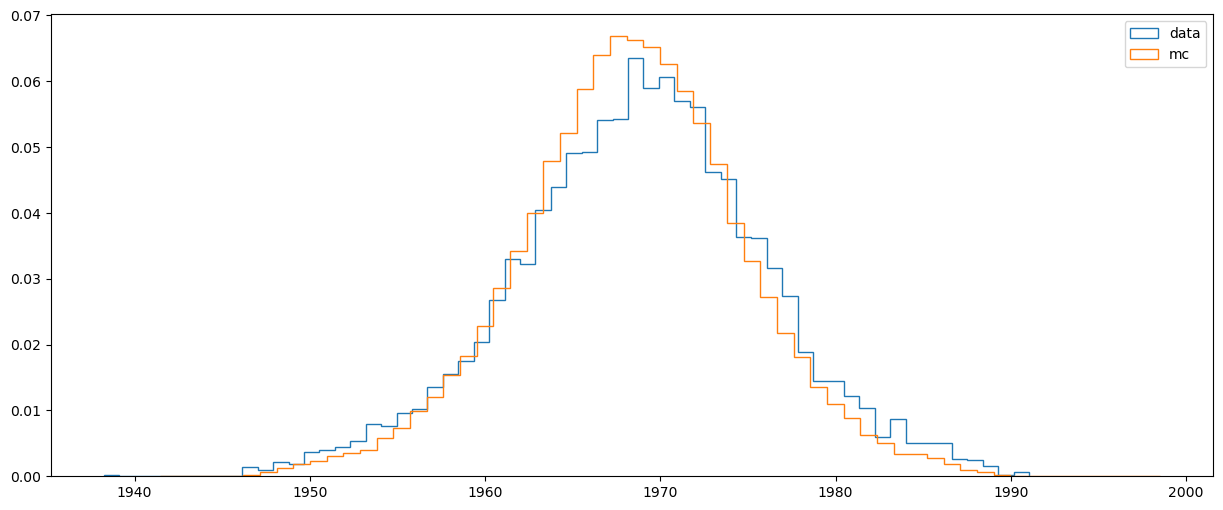

In [15]:
myrange=None
dres = plt.hist(data_norm_p.Xc_M, bins=60, 
         label= 'data', histtype='step', range=myrange, density=True);
mcres = plt.hist(mc_norm_p.Xc_M, bins=60, 
         label= 'mc', histtype='step', range=myrange, density=True);
plt.legend();

In [16]:
expr = "B_M > 5346 and B_M < 5386 and Xc_M > 1958 and Xc_M < 1978"
data_norm_p = data_norm.query(expr)
mc_norm_p = mc_norm.query(expr)
print(f"Ratio MC/data for canditates: {mc_norm_p.shape[0]/data_norm_p.shape[0]}")

Ratio MC/data for canditates: 12.509498787388845


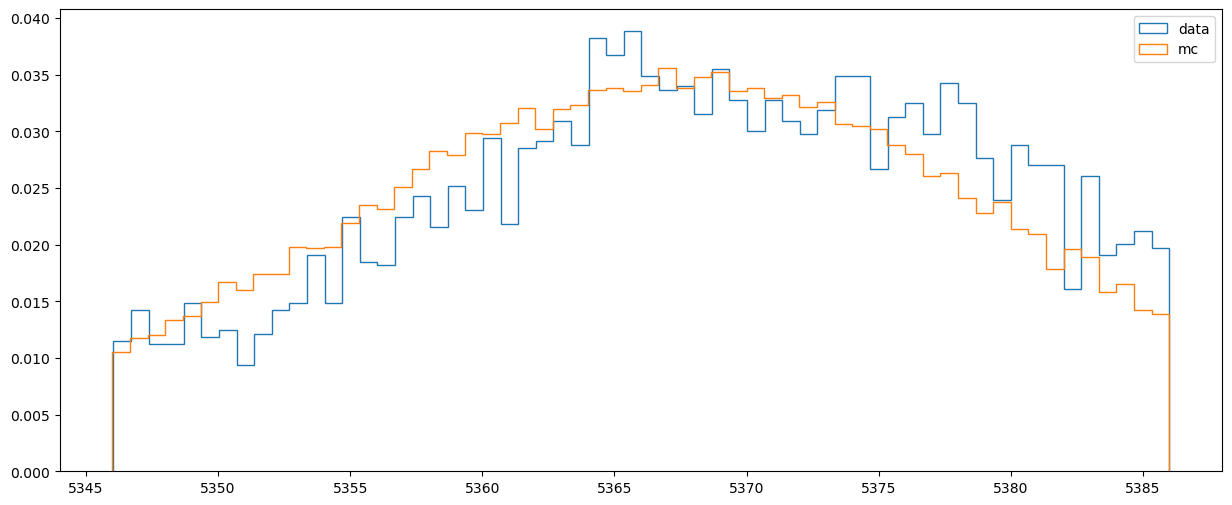

In [17]:
myrange=None
dres = plt.hist(data_norm_p.B_M, bins=60, 
         label= 'data', histtype='step', range=myrange, density=True);
mcres = plt.hist(mc_norm_p.B_M, bins=60, 
         label= 'mc', histtype='step', range=myrange, density=True);
plt.legend();

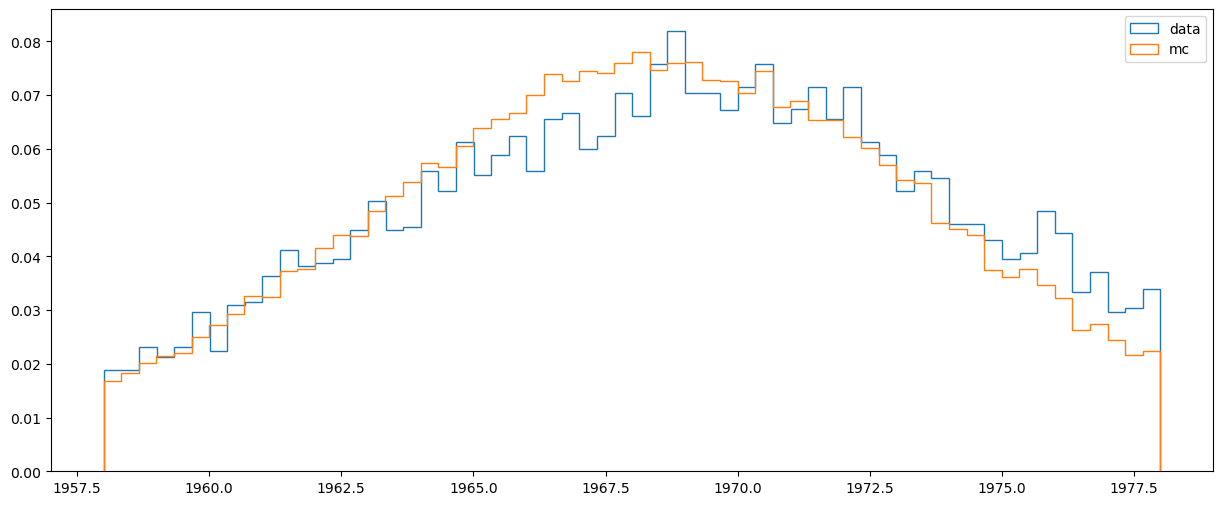

In [18]:
myrange=None
dres = plt.hist(data_norm_p.Xc_M, bins=60, 
         label= 'data', histtype='step', range=myrange, density=True);
mcres = plt.hist(mc_norm_p.Xc_M, bins=60, 
         label= 'mc', histtype='step', range=myrange, density=True);
plt.legend();

In [19]:
mygroupby(mc_norm_p, "key")

,key,count,Percentage,cumulative %
0,Xc_signal_Ypis_B_vertex_fromBs,55405,89.511608,89.511608
1,Xc_background,3196,5.163417,94.675025
2,Xc_signal_Ypis_nomatch_Prompt,2173,3.510671,98.185696
3,Xc_signal_Ypis_displaced_fromBs_fromDs,655,1.058210,99.243905
4,Xc_signal_Ypis_diffVertex_normlike,182,0.294037,99.537942
5,Xc_signal_Ypis_nomatch_doubleCharm,119,0.192255,99.730197
6,Xc_signal_Ypis_displaced_fromLambdab_fromLambdac,42,0.067855,99.798052
7,Xc_signal_Ypis_diffAncestorYXc,39,0.063008,99.861060
8,Xc_signal_Ypis_nomatch_charmStrange,36,0.058161,99.919221
9,Xc_signal_Ypis_displaced_fromBs_fromDp,13,0.021003,99.940223


## Investigating the excedent of data with B_M < 5100 MeV

In [19]:
expr = "B_M > 5000 and B_M < 5100"
data_pb = data_norm.query(expr)
mc_pb = mc_norm.query(expr)
print(f"Ratio MC/data for candidates: {mc_pb.shape[0]/data_pb.shape[0]}")

Ratio MC/data for candidates: 4.075321162947938


In [20]:
mygroupby(mc_pb, "key")

,key,count,Percentage,cumulative %
0,Xc_signal_Ypis_B_vertex_fromBs,20281,67.296015,67.296015
1,Xc_background,2450,8.129542,75.425557
2,Xc_signal_Ypis_displaced_fromBs_fromDs,1847,6.128679,81.554236
3,Xc_signal_Ypis_nomatch_Prompt,1451,4.814680,86.368915
4,Xc_signal_Ypis_displaced_fromB0_fromDp,1287,4.270498,90.639413
5,Xc_signal_Ypis_diffVertex_CharmStrange,598,1.984272,92.623685
6,Xc_signal_Ypis_nomatch_doubleCharm,510,1.692272,94.315957
7,Xc_signal_Ypis_displaced_fromLambdab_fromLambdac,332,1.101636,95.417593
8,Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB,324,1.075090,96.492683
9,Xc_signal_Ypis_diffVertex_normlike,277,0.919136,97.411819


In [21]:
def myplot(data, mc, v, pbins=60, prange=None):
    dres = plt.hist(data[v], bins=pbins, 
                    label= 'data', histtype='step', range=prange, density=True);
    mcres = plt.hist(mc[v], bins=pbins, 
                     label= 'mc', histtype='step', range=prange, density=True);
    plt.legend();
    

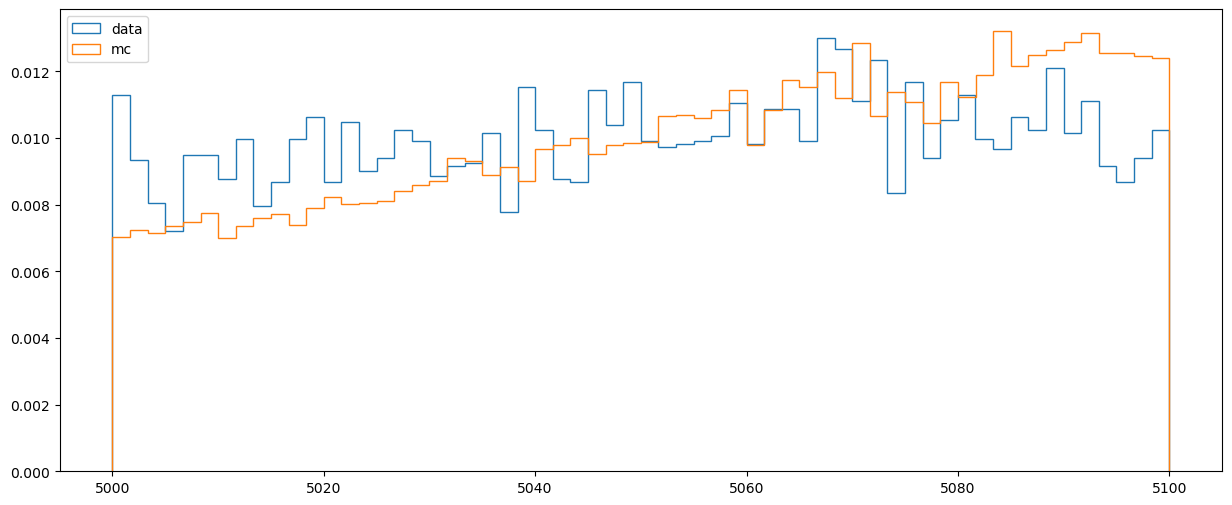

In [22]:
myplot(data_pb, mc_pb, 'B_M')

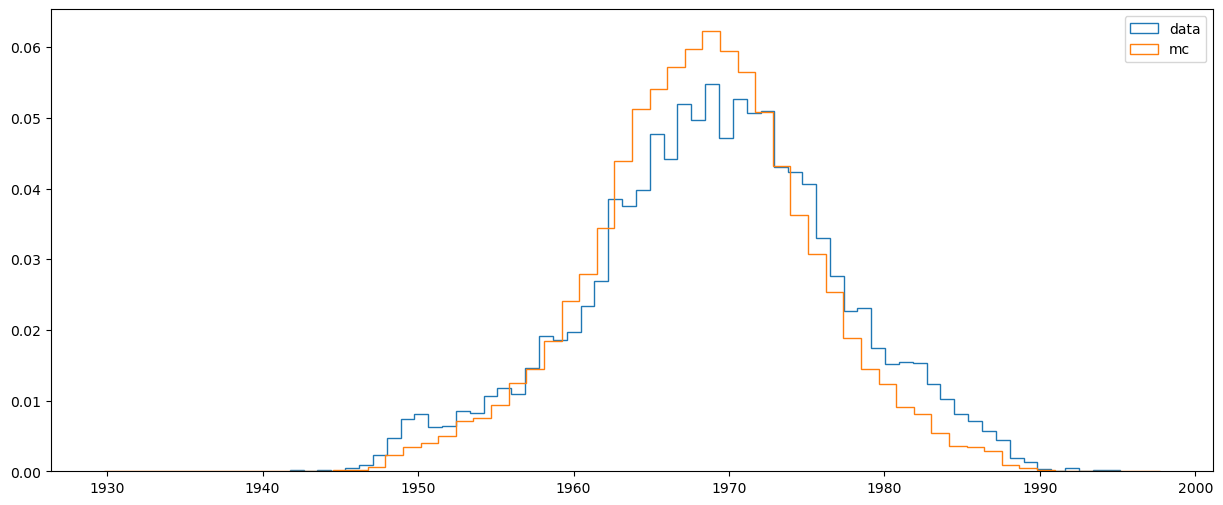

In [23]:
myplot(data_pb, mc_pb, 'Xc_M')

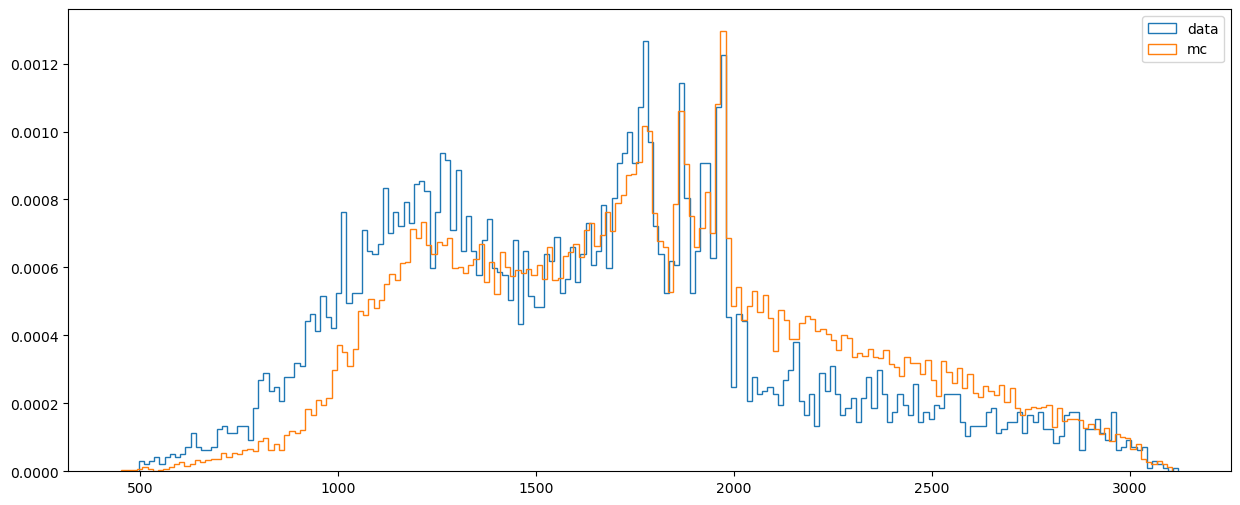

In [24]:
myplot(data_pb, mc_pb, 'Y_M', pbins=200)

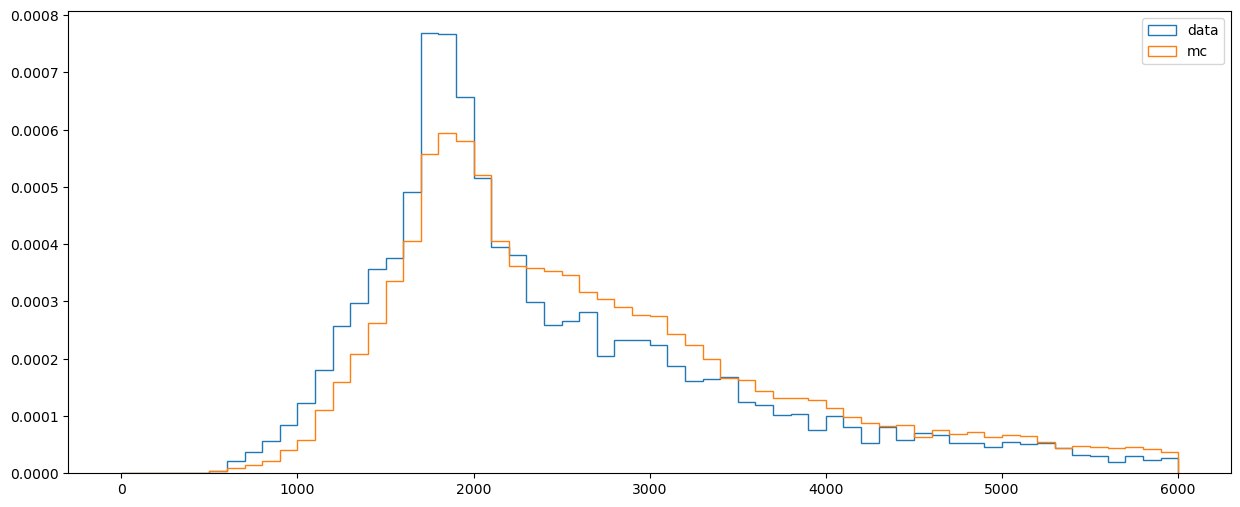

In [25]:
myplot(data_pb, mc_pb, 'Y_correctedMass', prange=[0, 6000])

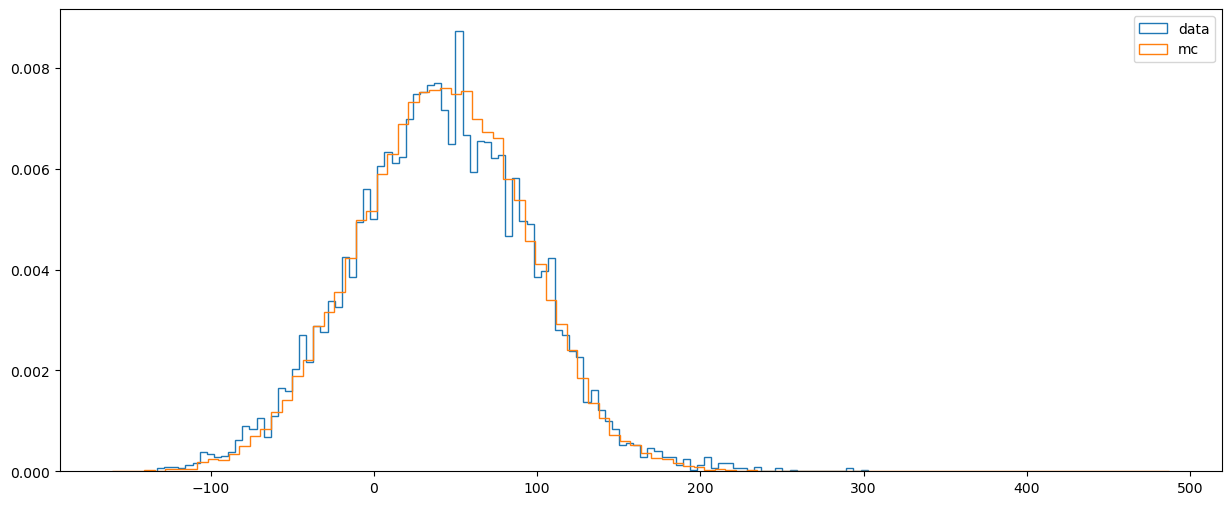

In [26]:
myplot(data_pb, mc_pb, 'Y_ENDVERTEX_Z', pbins=100)

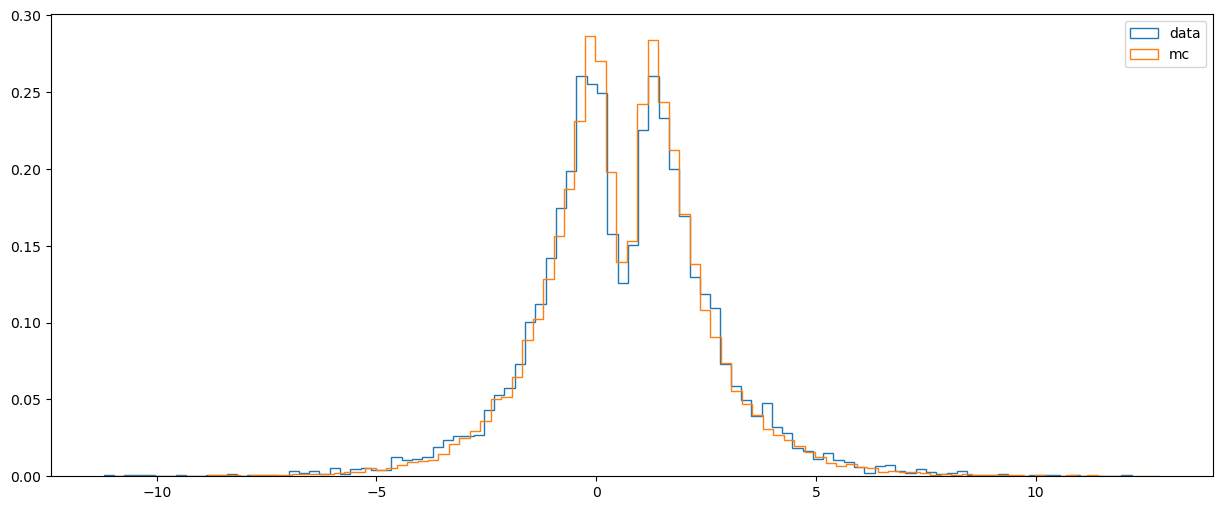

In [27]:
myplot(data_pb, mc_pb, 'Y_ENDVERTEX_X', pbins=100)

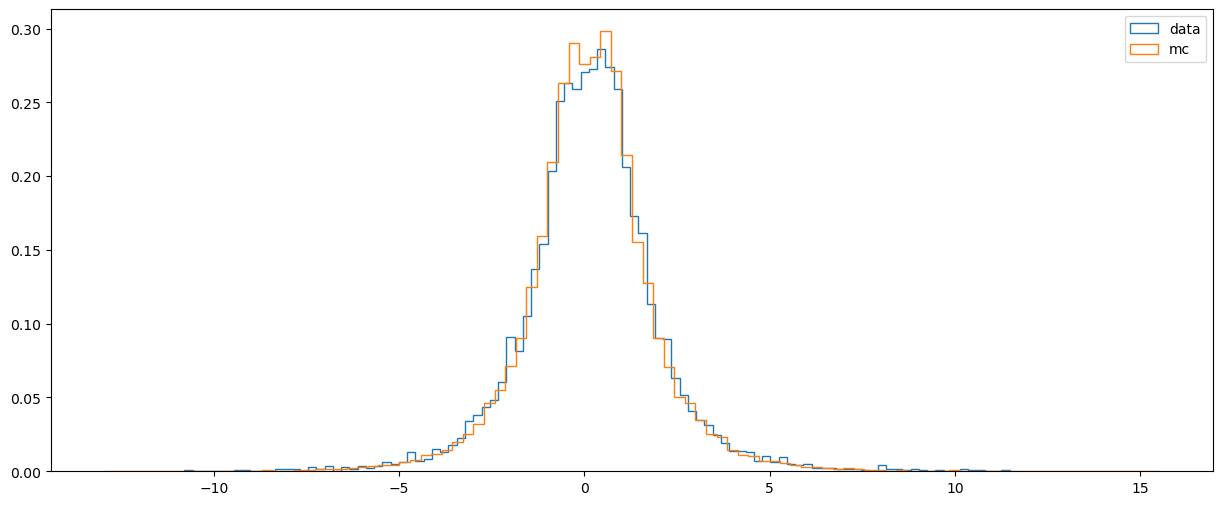

In [28]:
myplot(data_pb, mc_pb, 'Y_ENDVERTEX_Y', pbins=100)

In [29]:
data_pb.columns

Index(['BDT_3pi', 'BDT_Bs', 'BDT_Ds', 'BDT_Iso', 'B_BPVVDR', 'B_ENDVERTEX_X',
       'B_ENDVERTEX_Y', 'B_ENDVERTEX_Z', 'B_ENDVERTEX_ZERR', 'B_ETA', 'B_M',
       'B_MM', 'B_P', 'B_PT', 'B_Y_SEP', 'B_correctedMass', 'B_pT_Bdir',
       'PBsn', 'PBv', 'PBvn', 'Xc_ENDVERTEX_CHI2', 'Xc_ENDVERTEX_X',
       'Xc_ENDVERTEX_Y', 'Xc_ENDVERTEX_Z', 'Xc_ETA', 'Xc_FD_ORIVX',
       'Xc_FD_OWNPV', 'Xc_M', 'Xc_MM', 'Xc_PT', 'Y_0_20_cc_PZ',
       'Y_0_20_cc_mult', 'Y_0_30_nc_PZ', 'Y_0_40_nc_PZ', 'Y_0_40_nc_mult',
       'Y_BPVVDR', 'Y_ENDVERTEX_X', 'Y_ENDVERTEX_Y', 'Y_ENDVERTEX_Z',
       'Y_ENDVERTEX_ZERR', 'Y_M', 'Y_MM', 'Y_PE', 'Y_correctedMass',
       'eventIndex', 'eventNumber', 'mDs2vn', 'mN2v', 'max_m2pi', 'min_m2pi',
       'missing_mass_2', 'missing_pY_mass', 'nCandidate', 'nSPDHits',
       'nTracks', 'q2_2', 'tauY_2', 'totCandidates', 'log(abs(PBsn))',
       'log(abs(PBv/B_P))', 'log(abs(PBvn/B_P))', 'log(abs((PBsn-PBvn)/PBvn))',
       'log(sqrt(abs(mDs2vn)))', 'log(Y_PE)', 'diff_m2pi',

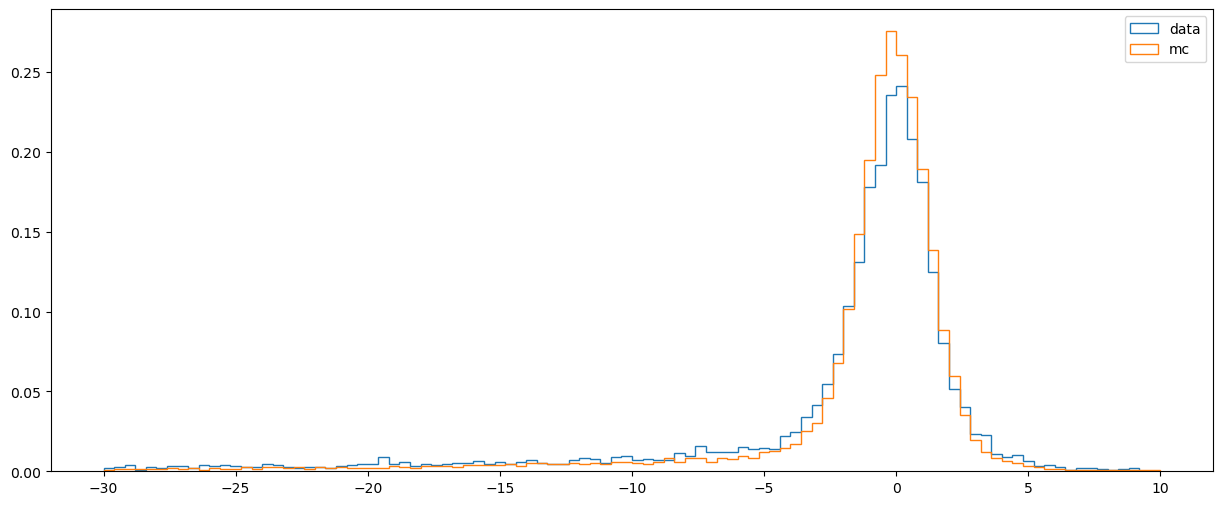

In [30]:
myrange=[-30, 10]
dres = plt.hist(data_pb.B_Y_SEP, bins=100, 
         label= 'data', histtype='step', range=myrange, density=True);
mcres = plt.hist(mc_pb.B_Y_SEP, bins=100, 
         label= 'mc', histtype='step', range=myrange, density=True);
plt.legend();

In [31]:
expr = "B_M > 5346 and B_M < 5386 and B_Y_SEP > -4.5"
data_norm_p = data_norm.query(expr)
mc_norm_p = mc_norm.query(expr)
print(f"Ratio MC/data for canditates: {mc_norm_p.shape[0]/data_norm_p.shape[0]}")

Ratio MC/data for canditates: 12.131141808008394


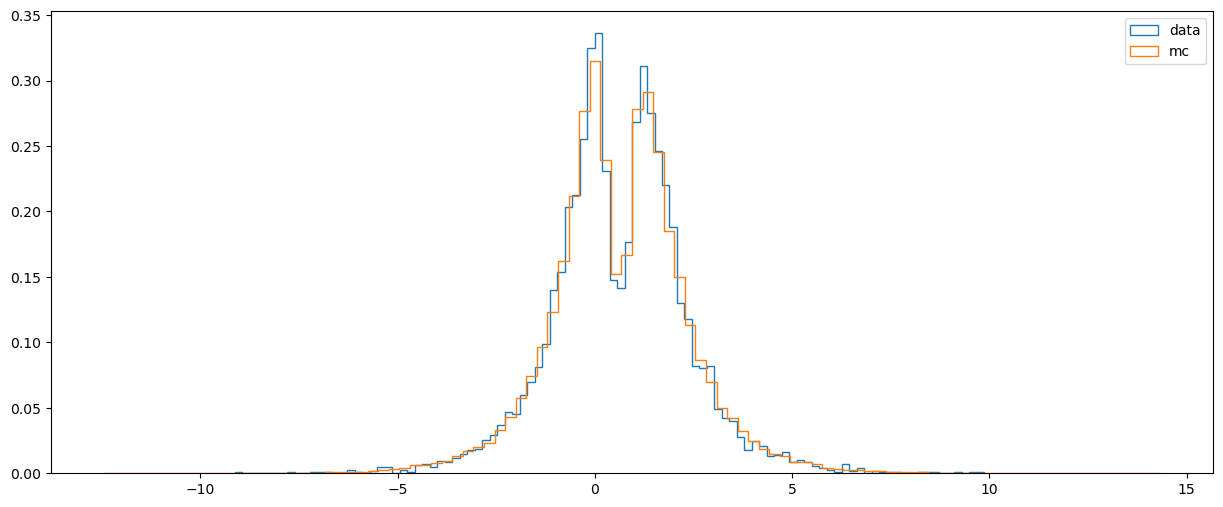

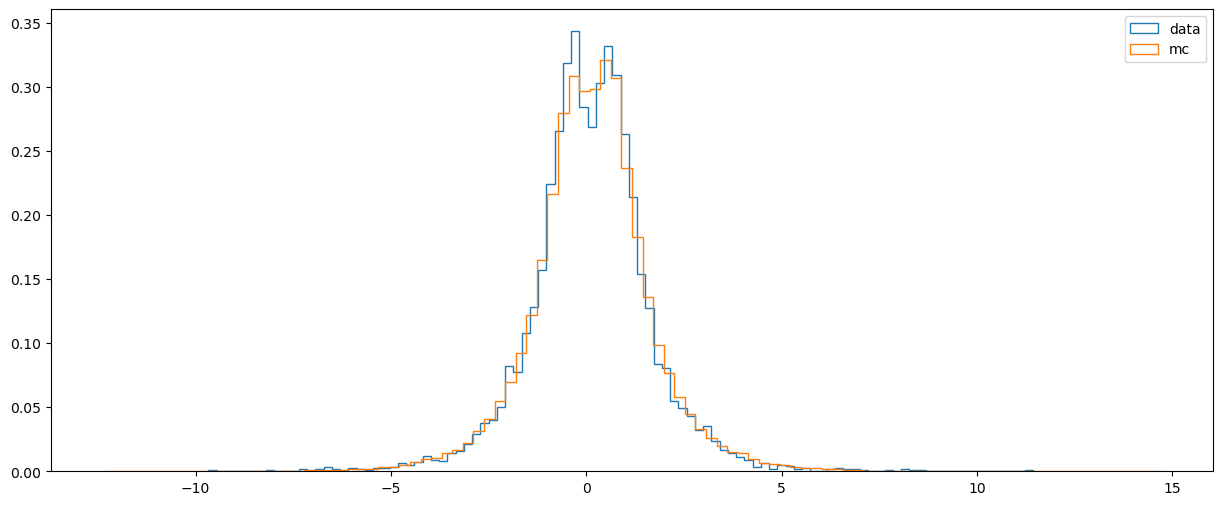

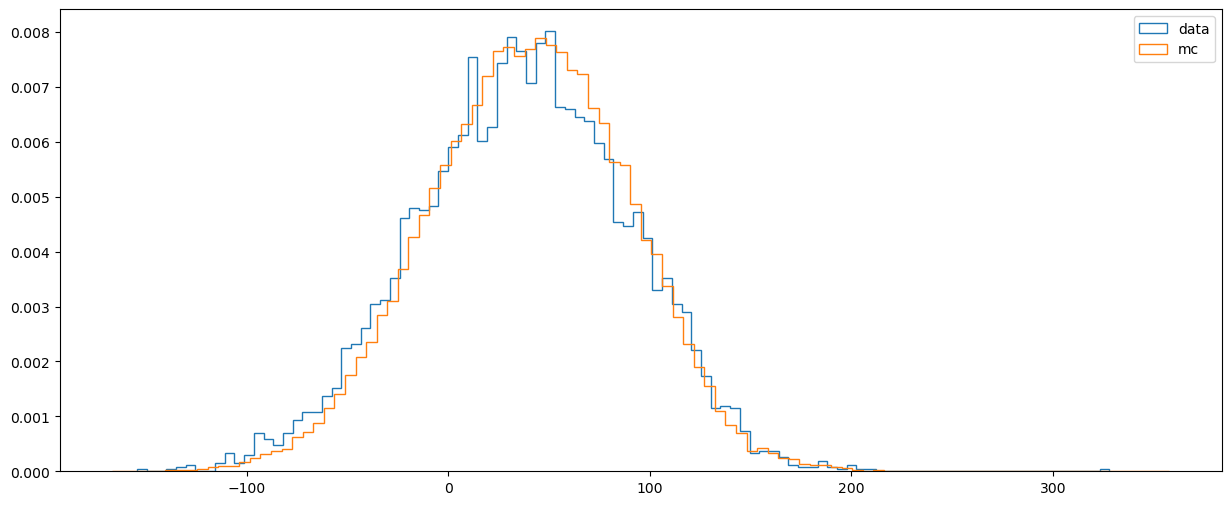

In [32]:
myplot(data_norm_p, mc_norm_p, 'Y_ENDVERTEX_X', pbins=100)
plt.figure()
myplot(data_norm_p, mc_norm_p, 'Y_ENDVERTEX_Y', pbins=100)
plt.figure()
myplot(data_norm_p, mc_norm_p, 'Y_ENDVERTEX_Z', pbins=100)

In [35]:
expr = "B_M > 5326 and B_M < 5406"
tmp_ds3pi = ds3pi_norm.query(expr)
tmp_data = data_norm.query(expr)
print(f"Ratio MC/data for candidates: {tmp_ds3pi.shape[0]/tmp_data.shape[0]}")

Ratio MC/data for candidates: 5.46521300731031
